# 🩹 Wound Image Segmentation using U-Net

This project implements a U-Net based deep learning model for automated wound segmentation in clinical images.

Author: Tanya Agrawal  
Framework: PyTorch  
Domain: AI in Healthcare

In [24]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam


In [25]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


## 📂 Dataset

- Binary wound segmentation dataset
- Images resized to 224×224
- Masks converted to binary format (0 = background, 1 = wound)

Dataset not uploaded due to privacy constraints.

In [26]:
class WoundDataset(Dataset):
    def __init__(self, img_dir, mask_dir, size=224):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.size = size

        self.images = sorted(os.listdir(img_dir))
        self.masks  = sorted(os.listdir(mask_dir))

        assert len(self.images) == len(self.masks), \
            "Mismatch between images and masks count"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name  = self.images[idx]
        mask_name = self.masks[idx]

        # ---------- IMAGE ----------
        img = cv2.imread(os.path.join(self.img_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.size, self.size))
        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)

        # ---------- MASK ----------
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name),
                           cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.size, self.size),
                           interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.float32)
        mask = torch.tensor(mask).unsqueeze(0)

        return img, mask


In [ ]:
# This section requires local dataset
# Not executed in GitHub version

if False:
    train_dataset = WoundDataset(
        img_dir='data/train_images',
        mask_dir='data/train_masks'
    )

    test_dataset = WoundDataset(
        img_dir='data/test_images',
        mask_dir='data/test_masks'
    )

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


## 🧠 Model Architecture

We use U-Net, a convolutional neural network designed for biomedical image segmentation.

Architecture Components:
- Encoder (Conv + ReLU + BatchNorm)
- Bottleneck
- Decoder (Upsampling)
- Skip connections

Loss Function:
- Binary Cross Entropy + Dice Loss

Optimizer:
- Adam (lr=3e-4)

Epochs:
- 20

In [28]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


In [29]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b  = self.bottleneck(self.pool(e2))

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)


In [30]:
model = UNet().to(device)


In [31]:
class DiceLoss(nn.Module):
    def forward(self, logits, masks):
        probs = torch.sigmoid(logits)
        smooth = 1.0
        intersection = (probs * masks).sum()
        return 1 - (2*intersection + smooth) / (
            probs.sum() + masks.sum() + smooth
        )


In [32]:
loss_fn = lambda x, y: \
    nn.BCEWithLogitsLoss()(x, y) + DiceLoss()(x, y)


In [33]:
optimizer = Adam(model.parameters(), lr=3e-4)

## 🔍 Model Predictions

Green → Predicted Mask  
Red → Ground Truth  

Overlap region indicates segmentation accuracy.

In [34]:
if False:
    train_dice_history = []
    train_loss_history = []

    for epoch in range(20):
        model.train()
        epoch_loss = 0
        epoch_dice = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            logits = model(imgs)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_dice += dice_score(logits, masks)

        avg_loss = epoch_loss / len(train_loader)
        avg_dice = epoch_dice / len(train_loader)

        train_loss_history.append(avg_loss)
        train_dice_history.append(avg_dice)

        if (epoch+1) % 5 == 0:
         print(
             f"Epoch {epoch+1:02d} | "
             f"Loss: {avg_loss:.4f} | "
             f"Dice: {avg_dice:.4f}"
         )


Epoch 05 | Loss: 0.5668 | Dice: 0.5679
Epoch 10 | Loss: 0.4309 | Dice: 0.6499
Epoch 15 | Loss: 0.3919 | Dice: 0.6930
Epoch 20 | Loss: 0.3591 | Dice: 0.7179


In [35]:
if False:
    model.eval()
    with torch.no_grad():
        imgs, masks = next(iter(test_loader))
        imgs = imgs.to(device)
        preds = torch.sigmoid(model(imgs))
        preds = (preds > 0.5).float()

In [36]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_prediction(model, dataset, index=0):
    model.eval()

    img, gt_mask = dataset[index]
    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(img_input))[0, 0]
        pred = (pred > 0.5).cpu().numpy()

    img = img.permute(1, 2, 0).cpu().numpy()
    gt_mask = gt_mask[0].cpu().numpy()

    # ---------- OVERLAY CREATION ----------
    overlay = np.zeros((*gt_mask.shape, 3), dtype=np.float32)

    overlay[..., 0] = gt_mask            # Red → Ground truth
    overlay[..., 1] = pred               # Green → Prediction
    overlay[..., 2] = 0                  # Blue unused

    # ---------- PLOTTING ----------
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gt_mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(img)
    plt.imshow(overlay, alpha=0.5)
    plt.title("Overlay (GT=Red, Pred=Green)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


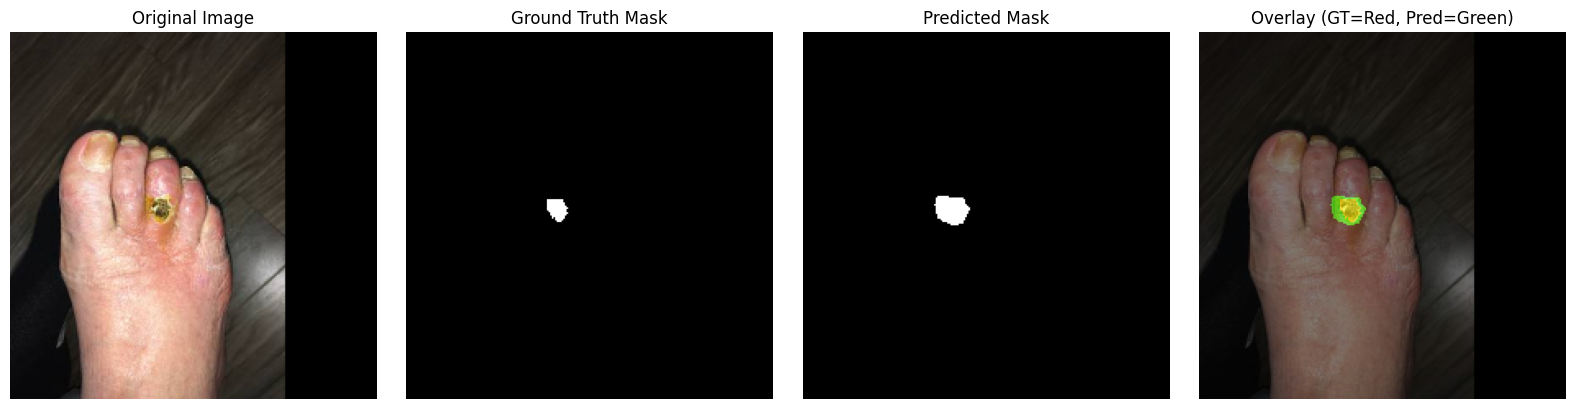

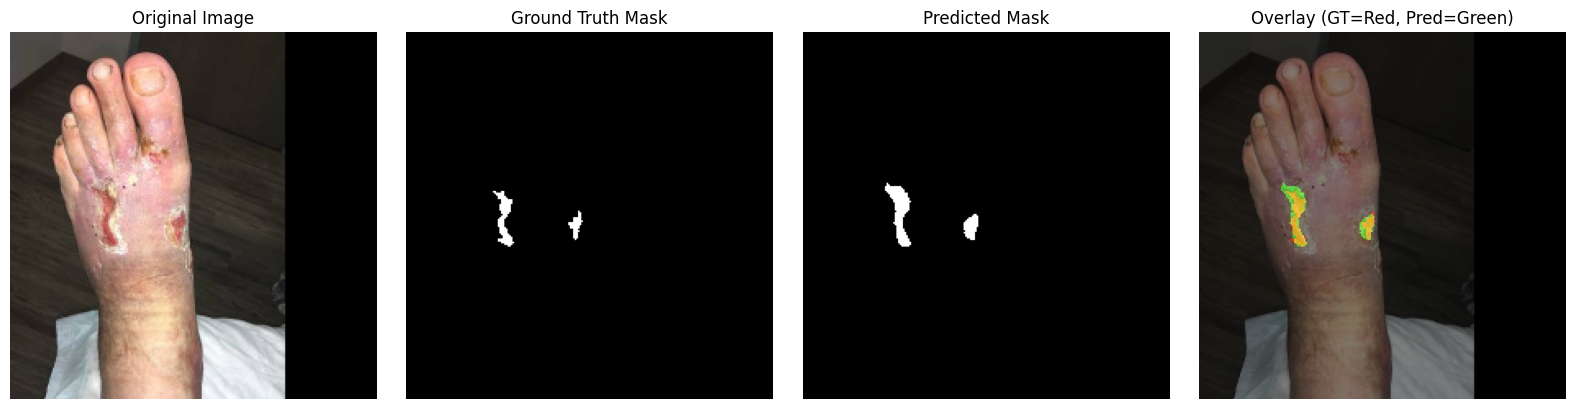

In [43]:
visualize_prediction(model, test_dataset, index=0)
visualize_prediction(model, test_dataset, index=5)

In [38]:
def dice_score(logits, masks, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * masks).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3))

    dice = (2 * intersection + 1e-7) / (union + 1e-7)
    return dice.mean().item()


## 📊 Training Performance

The model was trained for 20 epochs.
We track:

- Training Loss
- Dice Score

Dice Score measures overlap between predicted and ground truth masks.

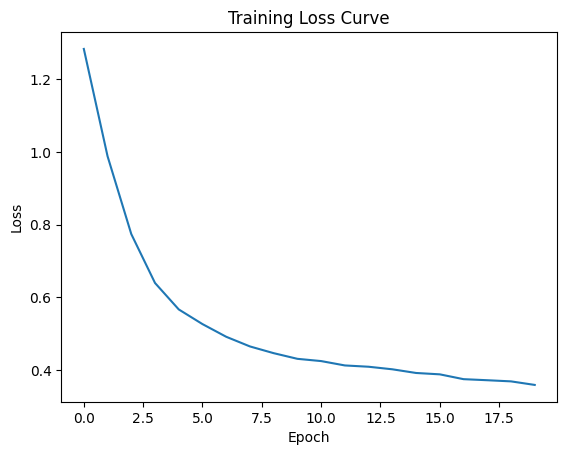

In [39]:
# plt.figure()
# plt.plot(train_loss_history)
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training Loss Curve")
# plt.show()

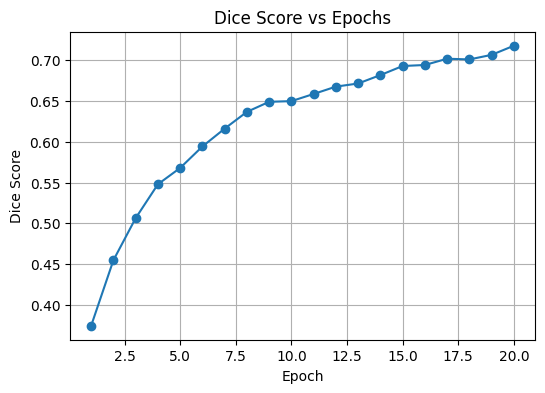

In [40]:
import matplotlib.pyplot as plt

# epochs = range(1, len(train_dice_history) + 1)

# plt.figure(figsize=(6, 4))
# plt.plot(epochs, train_dice_history, marker='o')
# plt.xlabel("Epoch")
# plt.ylabel("Dice Score")
# plt.title("Dice Score vs Epochs")
# plt.grid(True)
# plt.show()


In [41]:
if False:
    import torch

    model.eval()

    total_intersection = 0
    total_pred_pixels = 0
    total_gt_pixels = 0
    smooth = 1e-6

    with torch.no_grad():
         for images, masks in test_loader:
             images = images.to(device)
             masks = masks.to(device)

             outputs = torch.sigmoid(model(images))
             preds = (outputs > 0.5).float()

             total_intersection += (preds * masks).sum().item()
             total_pred_pixels += preds.sum().item()
             total_gt_pixels += masks.sum().item()

    overall_dice = (2 * total_intersection + smooth) / \
                    (total_pred_pixels + total_gt_pixels + smooth)

    print(f"Overall Dice Score on Test Data: {overall_dice:.4f}")

Overall Dice Score on Test Data: 0.7914


## ✅ Final Results

Training Dice Score ≈ 0.72  
Test Dice Score ≈ 0.79  

The model demonstrates effective wound segmentation using deep learning.

Future Work:
- Data augmentation
- Larger dataset
- Hyperparameter tuning
- Deployment using Streamlit